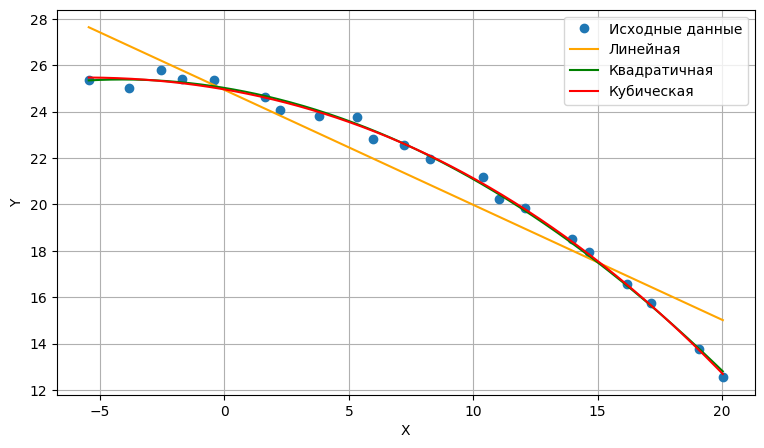

In [27]:
from numpy import *
from numpy.random import *
import matplotlib.pyplot as plt

delta = 1.0
x = linspace(-5, 20, 21)                 # точки по оси X
y = 25 - 0.2*x - 0.02*x**2               # некая зависимость
y += delta*(rand(len(x)) - 0.5)          # добавляем шум к Y
x += delta*(rand(len(x)) - 0.5)          # и к X, как в примере


# Линейная регрессия
m_lin = vstack((x, ones(len(x)))).T
s_lin = linalg.lstsq(m_lin, y, rcond=None)[0]

# Квадратичная регрессия:
m_quad = vstack((x**2, x, ones(len(x)))).T
s_quad = linalg.lstsq(m_quad, y, rcond=None)[0]

# Кубическая регрессия:
m_cub = vstack((x**3, x**2, x, ones(len(x)))).T
s_cub = linalg.lstsq(m_cub, y, rcond=None)[0]

#Точки для гладких кривых
x_prec = linspace(x.min(), x.max(), 400)

y_lin  = s_lin[0]*x_prec + s_lin[1]
y_quad = s_quad[0]*x_prec**2 + s_quad[1]*x_prec + s_quad[2]
y_cub  = s_cub[0]*x_prec**3 + s_cub[1]*x_prec**2 + s_cub[2]*x_prec + s_cub[3]

plt.figure(figsize=(9, 5))

plt.plot(x, y, 'o', label='Исходные данные')

plt.plot(x_prec, y_lin, color='orange', label='Линейная')

# квадратичная экстраполяция
plt.plot(x_prec, y_quad, color='green', label='Квадратичная')

# кубическая экстраполяция
plt.plot(x_prec, y_cub, color='red', label='Кубическая')

plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.legend()

plt.show()


Линейная оптимальные параметры: [1.7211929  1.10731512]
Сумма квадратов отклонений: 5.571156804390636 



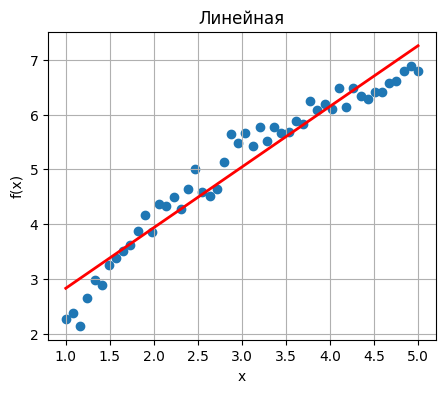

Квадратичная оптимальные параметры: [ 0.01463442  2.45243092 -0.22418597]
Сумма квадратов отклонений: 1.7040968758372572 



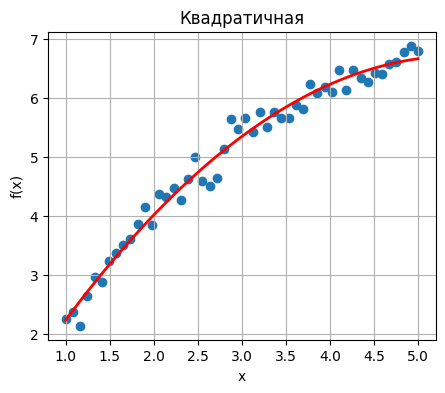

Логарифмическая оптимальные параметры: [2.04295304 2.97771241]
Сумма квадратов отклонений: 1.6184708920879405 



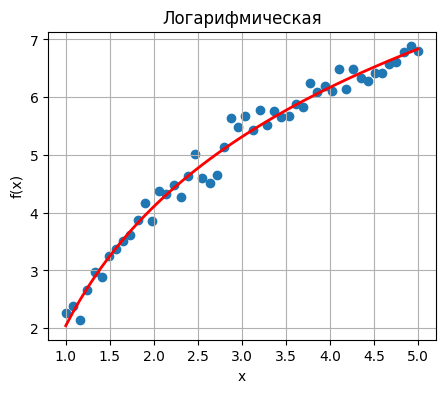

Степенная оптимальные параметры: [2.60226772 0.62163123]
Сумма квадратов отклонений: 3.318285178916825 



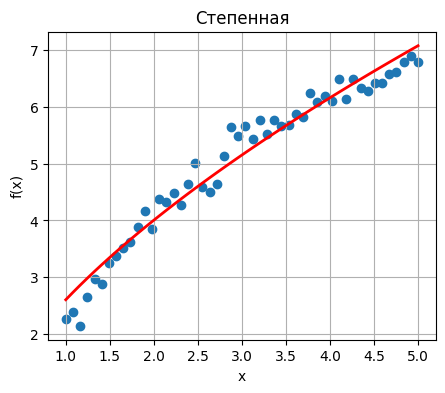

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# исходные данные
np.random.seed(10)
x = np.linspace(1, 5, 50)
y_true = 2 + 3*np.log(x)
y = y_true + 0.2*np.random.randn(len(x))   # добавили шум

# линейная, квадратичная, логорифмическая, степенная
def f1(x, b0, b1): return b0 + b1*x
def f2(x, b0, b1, b2): return b0 + b1*x + b2*x**2
def f3(x, b0, b1): return b0 + b1*np.log(x)
def f4(x, b0, b1): return b0 * x**b1

models = [f1, f2, f3, f4]
names  = ['Линейная', 'Квадратичная', 'Логарифмическая', 'Степенная']


for model, name in zip(models, names):
    popt, pcov = curve_fit(model, x, y, maxfev=5000) # подгоняем функцию
    y_pred = model(x, *popt)
    error = np.sum((y - y_pred)**2)

    print(name, "оптимальные параметры:", popt)
    print("Сумма квадратов отклонений:", error, "\n")

    plt.figure(figsize=(5,4))
    plt.scatter(x, y)
    plt.plot(x, y_pred, 'r', lw=2)
    plt.title(name)
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid()
    plt.show()


intercept: 26986.691316737248
coef: [9379.71049195]
   Результат    Предсказано
0    37731.0   41056.257055
1   122391.0  123597.709384
2    57081.0   65443.504334
3    63218.0   63567.562235
4   116969.0  116093.940990
5   109431.0  108590.172597
6   112635.0  117031.912039
7    55794.0   64505.533285


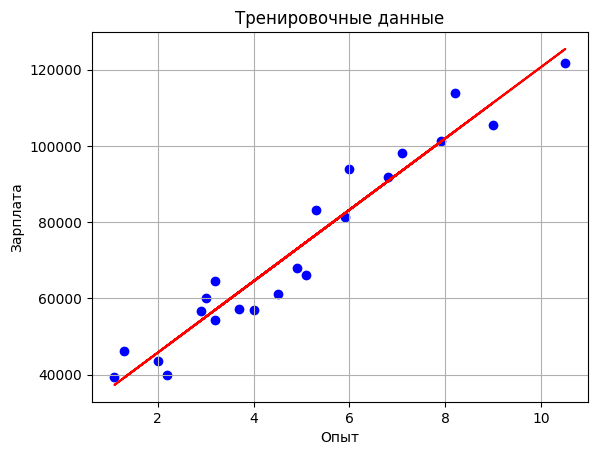

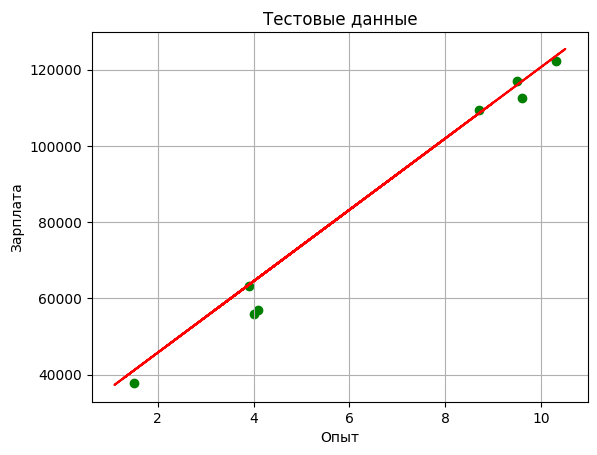

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

url = "https://raw.githubusercontent.com/AnnaShestova/salary-years-simple-linear-regression/master/Salary_Data.csv"
data = pd.read_csv(url)

# X — стаж, y — зарплата
X = data[['YearsExperience']].values
y = data['Salary'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

model = LinearRegression()
model.fit(X_train, y_train)

print("intercept:", model.intercept_)
print("coef:", model.coef_)

y_pred = model.predict(X_test)
print(pd.DataFrame({"Результат": y_test, "Предсказано": y_pred}))

# график train
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, model.predict(X_train), color='red')
plt.title("Тренировочные данные")
plt.xlabel("Опыт")
plt.ylabel("Зарплата")
plt.grid()
plt.show()

# график тест
plt.scatter(X_test, y_test, color='green')
plt.plot(X_train, model.predict(X_train), color='red')
plt.title("Тестовые данные")
plt.xlabel("Опыт")
plt.ylabel("Зарплата")
plt.grid()
plt.show()


   Petrol_tax  Average_income  Paved_Highways  Population_Driver_licence(%)  \
0         9.0            3571            1976                         0.525   
1         9.0            4092            1250                         0.572   
2         9.0            3865            1586                         0.580   
3         7.5            4870            2351                         0.529   
4         8.0            4399             431                         0.544   

   Petrol_Consumption  
0                 541  
1                 524  
2                 561  
3                 414  
4                 410  
(48, 5)
       Petrol_tax  Average_income  Paved_Highways  \
count   48.000000       48.000000       48.000000   
mean     7.668333     4241.833333     5565.416667   
std      0.950770      573.623768     3491.507166   
min      5.000000     3063.000000      431.000000   
25%      7.000000     3739.000000     3110.250000   
50%      7.500000     4298.000000     4735.500000   
75

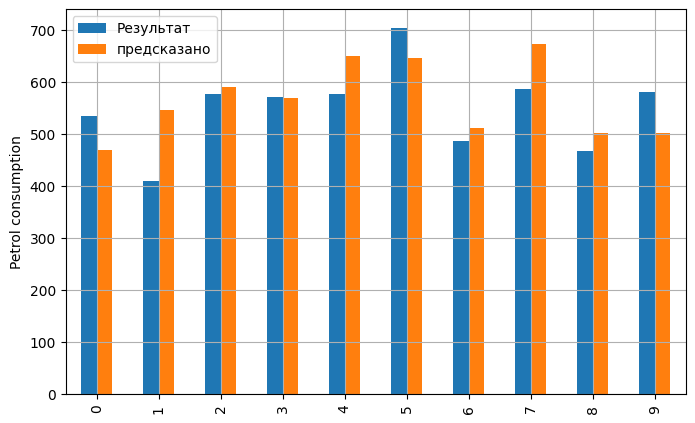

In [36]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

url = "https://raw.githubusercontent.com/likarajo/petrol_consumption/master/data/petrol_consumption.csv"
dataset = pd.read_csv(url)


print(dataset.head())
print(dataset.shape)
print(dataset.describe())


X = dataset.drop('Petrol_Consumption', axis=1)   # все столбцы, кроме целевого
y = dataset['Petrol_Consumption']                # целевой столбец


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# множественной линейной регрессии
regressor = LinearRegression()
regressor.fit(X_train, y_train)


print("Свободный член:", regressor.intercept_)
coeff_df = pd.DataFrame(regressor.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)


y_pred = regressor.predict(X_test)
result_df = pd.DataFrame({'Результат': y_test, 'предсказано': y_pred})
print(result_df)


mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)
print("среднеквадратичная ошибка:", mse)
print("корень среднеквадратичная ошибка", rmse)
print("коэффициент детерминации:", r2)         # как хорошо модель объясняет данные


result_df = result_df.reset_index(drop=True)
result_df.plot(kind='bar', figsize=(8,5))
plt.grid()
plt.ylabel('Petrol consumption')
plt.show()


Коэффициенты линейного полинома: a = -0.5714285714285721 , b = 4.285714285714284
Коэффициенты квадратичного полинома:
a = 8.035714285714285 , b = -8.607142857142858 , c = 5.357142857142858


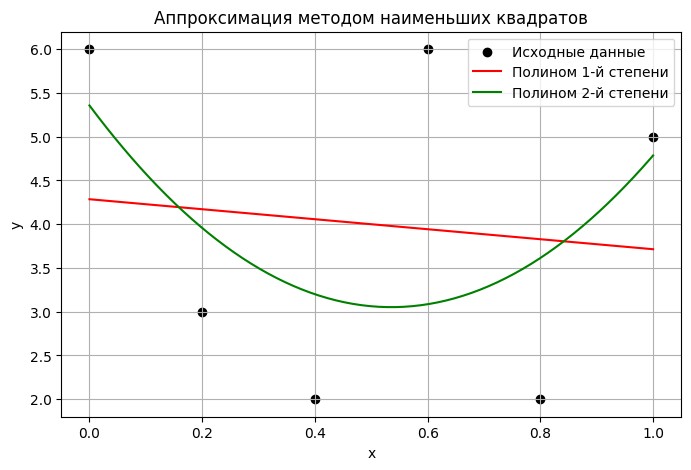

In [37]:
import numpy as np
import matplotlib.pyplot as plt


x = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
y = np.array([6.0, 3.0, 2.0, 6.0, 2.0, 5.0])

# Первая степень
A1 = np.vstack([x, np.ones(len(x))]).T
coeff1, *_ = np.linalg.lstsq(A1, y, rcond=None)

a1, b1 = coeff1
print("Коэффициенты линейного полинома: a =", a1, ", b =", b1)

# Вторая степень
A2 = np.vstack([x**2, x, np.ones(len(x))]).T
coeff2, *_ = np.linalg.lstsq(A2, y, rcond=None)

a2, b2, c2 = coeff2
print("Коэффициенты квадратичного полинома:")
print("a =", a2, ", b =", b2, ", c =", c2)

# Апроксимация
x_prec = np.linspace(0, 1, 200)
y_lin = a1*x_prec + b1
y_quad = a2*x_prec**2 + b2*x_prec + c2


plt.figure(figsize=(8,5))
plt.scatter(x, y, color='black', label='Исходные данные')

plt.plot(x_prec, y_lin, 'r', label='Полином 1-й степени')
plt.plot(x_prec, y_quad, 'g', label='Полином 2-й степени')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Аппроксимация методом наименьших квадратов")
plt.grid()
plt.legend()
plt.show()
